In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ==============================
# 1. CARGAR DATOS (CORREGIDO)
# ==============================
ruta = r'P:\estadistica\auto-mpg.data.txt'
columnas = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year', 'origin', 'car_name']

# Leer archivo
df = pd.read_csv(ruta, names=columnas, na_values='?', comment='\t',
                 sep=' ', skipinitialspace=True)

print("Dimensiones originales:", df.shape)
print("Valores nulos:\n", df.isnull().sum())

# Seleccionar solo columnas numéricas (excluir 'car_name')
cols_numericas = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                  'acceleration', 'model_year', 'origin']
df_clean = df[cols_numericas].copy()

# Eliminar filas con nulos en estas columnas (horsepower tiene 6)
df_clean = df_clean.dropna().reset_index(drop=True)

print("Dimensiones después de limpiar nulos:", df_clean.shape)
print("\nPrimeras 5 filas:")
print(df_clean.head())

# Guardar versión limpia
df_clean.to_csv('auto_mpg_limpio.csv', index=False)
print("\nArchivo guardado: auto_mpg_limpio.csv")

Dimensiones originales: (398, 9)
Valores nulos:
 mpg               0
cylinders         0
displacement      0
horsepower        6
weight            0
acceleration      0
model_year        0
origin            0
car_name        398
dtype: int64
Dimensiones después de limpiar nulos: (392, 8)

Primeras 5 filas:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  

Archivo guardado: auto_mpg_limpio.csv



=== ESTADÍSTICAS DESCRIPTIVAS ===
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year      origin  
count    392.000000  392.000000  392.000000  
mean      15.541327   75.979592    1.576531  
std        2.758864    3.683737    0.805518  
min        8.000000   70.000000    1.000000  
25%       13.775000   73.000000    1.000000  
50%       15.500000   76.000000    1.000

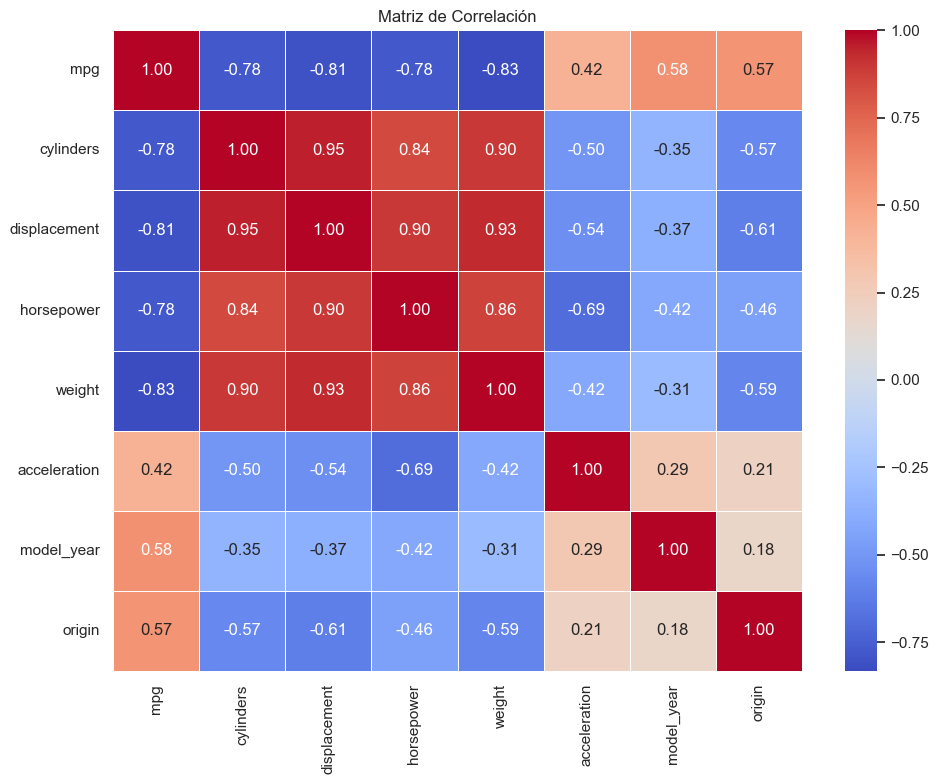

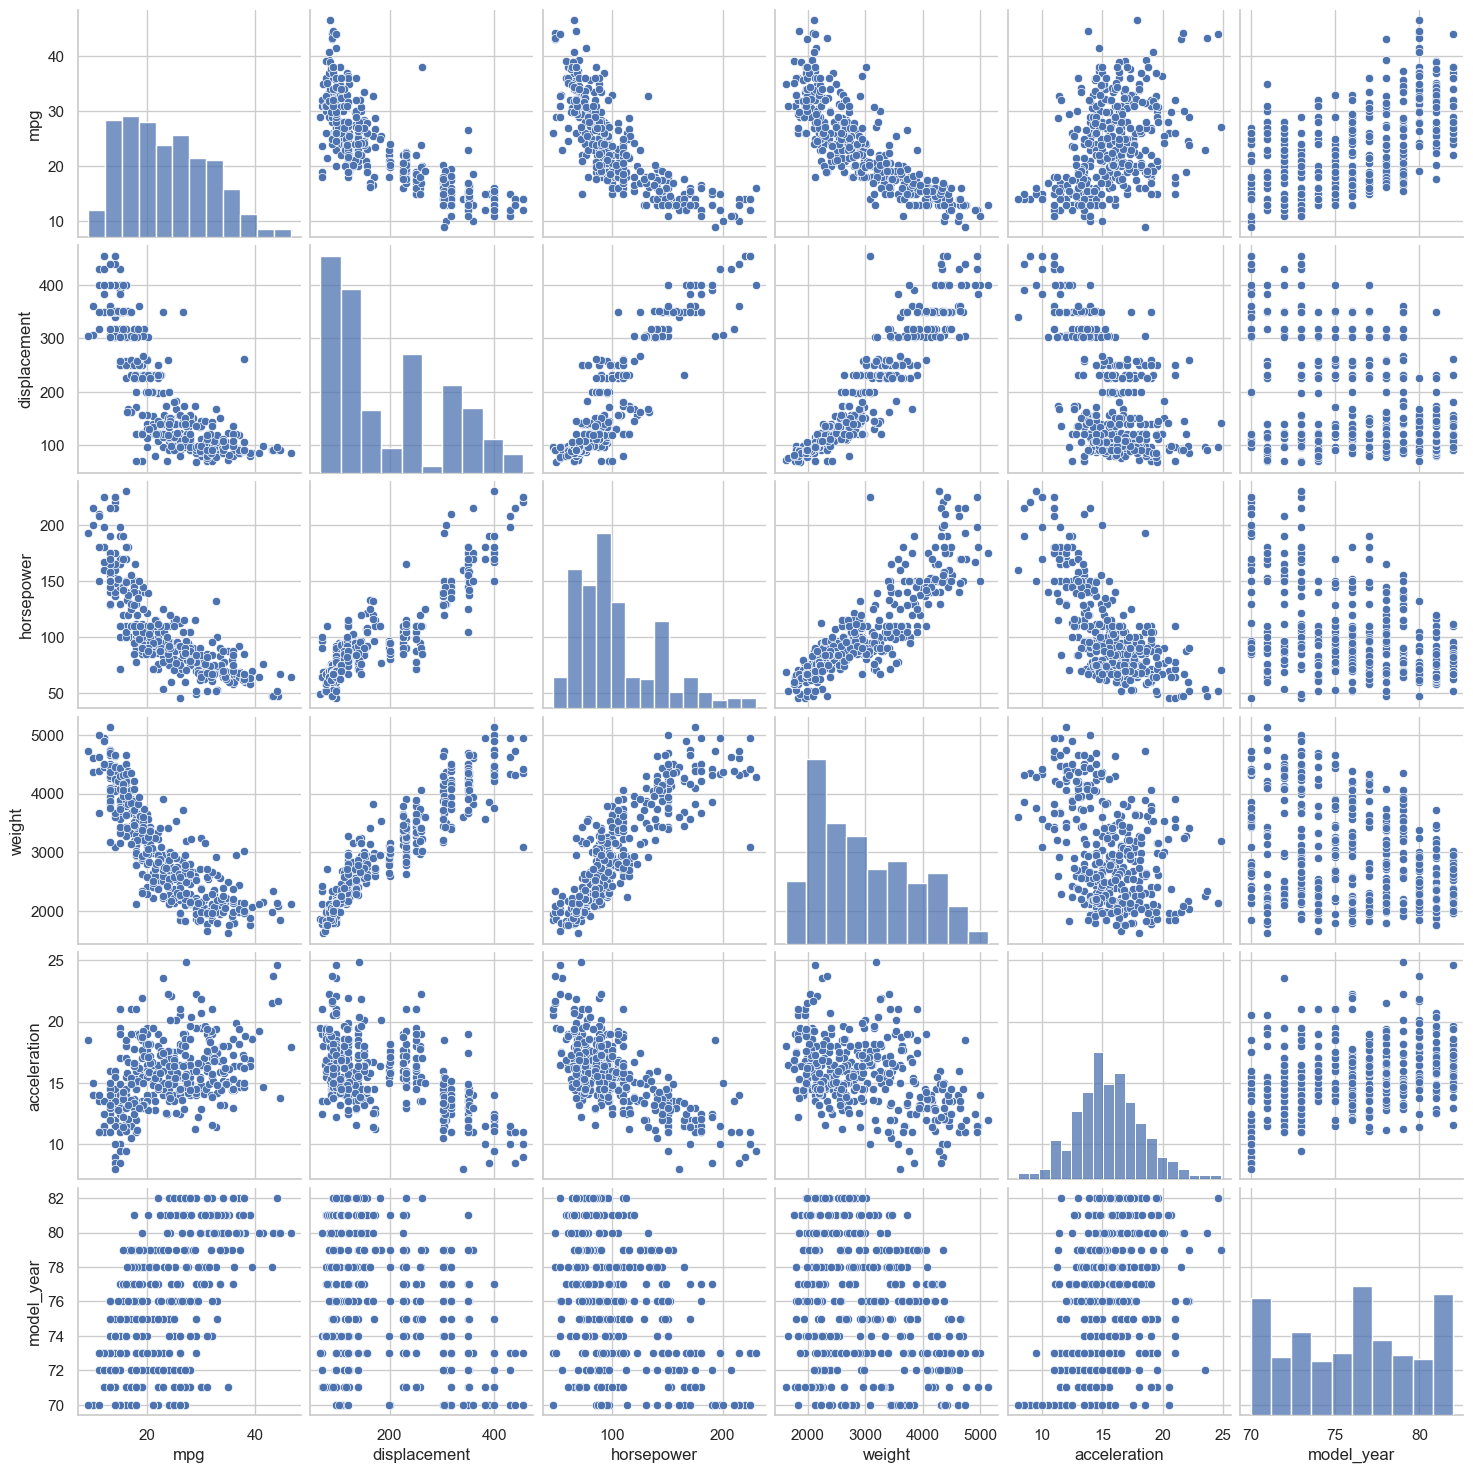


=== RESUMEN DEL MODELO ===
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.04e-139
Time:                        19:06:58   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2

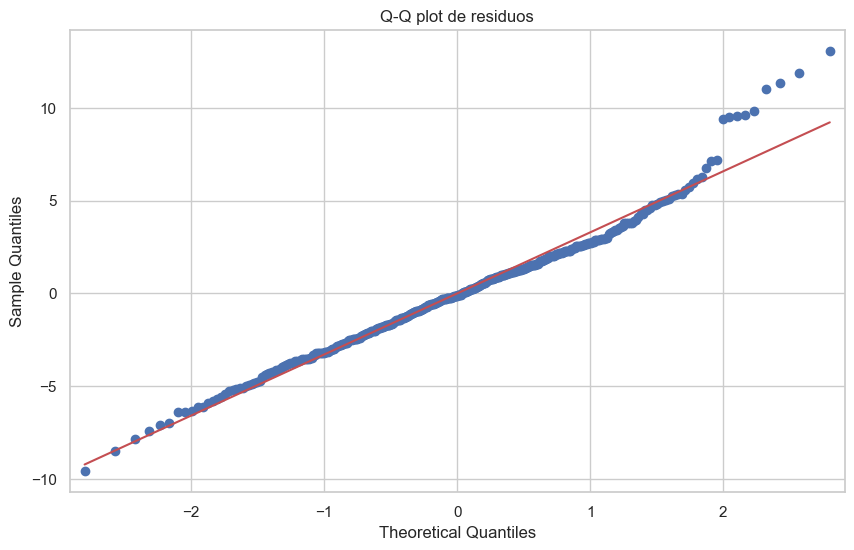


=== INDEPENDENCIA ===
Durbin-Watson: 1.3092 (valores entre 1.5 y 2.5 indican independencia)

=== MULTICOLINEALIDAD (VIF) ===
       Variable         VIF
0     cylinders  117.708547
1  displacement   96.909762
2    horsepower   67.072154
3        weight  139.454162
4  acceleration   69.699769
5    model_year  115.794614
6        origin    8.469942
⚠️ Hay variables con VIF > 10 (multicolinealidad severa)


In [ ]:
# ==============================
# 2. ESTADÍSTICAS DESCRIPTIVAS
# ==============================
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df_clean.describe())

# ==============================
# 3. MATRIZ DE CORRELACIÓN
# ==============================
corr = df_clean.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300)
plt.show()

# ==============================
# 4. PAIRPLOT (variables clave)
# ==============================
variables_clave = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
sns.pairplot(df_clean[variables_clave])
plt.savefig('pairplot.png', dpi=300)
plt.show()

# ==============================
# 5. MODELO DE REGRESIÓN LINEAL MÚLTIPLE
# ==============================
X = df_clean[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']]
y = df_clean['mpg']

# Agregar constante
X_const = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X_const).fit()

print("\n=== RESUMEN DEL MODELO ===")
print(modelo.summary())

# ==============================
# 6. COEFICIENTES E INTERVALOS DE CONFIANZA
# ==============================
coef = modelo.params
ic = modelo.conf_int()
ic.columns = ['IC 2.5%', 'IC 97.5%']
tabla_coef = pd.concat([coef, ic], axis=1)
tabla_coef.columns = ['Coeficiente', 'IC inferior', 'IC superior']
print("\n=== COEFICIENTES E INTERVALOS DE CONFIANZA (95%) ===")
print(tabla_coef)

# Coeficientes estandarizados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_const = sm.add_constant(X_scaled)
modelo_std = sm.OLS(y, X_scaled_const).fit()
betas = modelo_std.params[1:]
print("\n=== COEFICIENTES ESTANDARIZADOS (BETAS) ===")
print(betas.sort_values(ascending=False))
print(f"\nVariable con mayor impacto en mpg: {betas.abs().idxmax()} (beta = {betas.abs().max():.4f})")

# ==============================
# 7. RESPUESTAS A PREGUNTAS
# ==============================
print("\n=== RESPUESTAS A LAS PREGUNTAS ===")
print("1. ¿Qué variable afecta más el consumo?")
print(f"   → {betas.abs().idxmax()} (coeficiente estandarizado = {betas.abs().max():.4f})")
print("2. ¿El peso influye positiva o negativamente?")
print(f"   → Coeficiente de 'weight': {coef['weight']:.4f} (negativo → más peso, menos mpg)")
print("3. ¿Los carros más nuevos consumen menos combustible?")
print(f"   → Coeficiente de 'model_year': {coef['model_year']:.4f} (positivo → más nuevo, más mpg)")

# ==============================
# 8. VERIFICACIÓN DE SUPUESTOS
# ==============================
residuos = modelo.resid

# Normalidad
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"\n=== NORMALIDAD DE RESIDUOS ===")
print(f"Shapiro-Wilk: estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print(" Residuos normales")
else:
    print(" Residuos no normales")

# Q-Q plot
sm.qqplot(residuos, line='s')
plt.title('Q-Q plot de residuos')
plt.savefig('qqplot.png', dpi=300)
plt.show()

# Independencia (Durbin-Watson)
dw = durbin_watson(residuos)
print(f"\n=== INDEPENDENCIA ===")
print(f"Durbin-Watson: {dw:.4f} (valores entre 1.5 y 2.5 indican independencia)")

# Multicolinealidad (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n=== MULTICOLINEALIDAD (VIF) ===")
print(vif_data)
if (vif_data['VIF'] > 10).any():
    print(" Hay variables con VIF > 10 (multicolinealidad severa)")
else:
    print(" No hay multicolinealidad severa")